# Unified Evaluation — Length-Tolerant Features
# v1 (context-only) vs v2 (transaction-level) · Context lengths {1, 3, 6}

**Goal:** Compare original v1 risk/model features (degenerate at short context)
against new v2 features (intra-month transaction-level signals, stable at any context length).

Evaluates across `CONTEXT_LEN ∈ {1, 3, 6}` with shared data splits and pool caches.

| Section | Content |
|---|---|
| §1 | Configuration & data loading |
| §2 | Core helper functions |
| §3 | Feature function definitions (v1 vs v2) |
| §4 | Pipeline utilities (conformal, stratification) |
| §5 | Evaluation engine |
| §6 | Pre-compute scenarios & caches |
| §7 | Execute evaluation loop |
| §8 | Comparison dashboard |
| §9 | Summary |

## §1 · Configuration & Data Loading

In [1]:
import os, math, warnings, time
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import spearmanr

from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings('ignore')

# ── Pipeline configuration ────────────────────────────────────────────────────
CONTEXT_LENS = [1, 3, 6]
HORIZON_LEN  = 3
TARGET_COV   = 0.90
MIN_POOL     = 10
KNN_K        = 10

# ── Stratification guard (production values) ──────────────────────────────────
VOL_MIN_GAIN_ABS   = 0.05
VOL_MIN_GAIN_REL   = 0.01
VOL_TEST_COV_SLACK = 0.03
_VOL_EPS           = 1e-6

In [2]:
V2_CSV = 'df_5411_merchants_mthly_v2.csv'
V1_CSV = 'df_5411_merchants_mthly_25th_Mar.csv'

if os.path.exists(V2_CSV):
    df = pd.read_csv(V2_CSV)
    print(f'Loaded v2 CSV: {df.shape[0]:,} rows × {df.shape[1]} cols')
elif os.path.exists(V1_CSV):
    df = pd.read_csv(V1_CSV)
    print(f'⚠ v2 CSV not found — loaded v1 CSV: {df.shape[0]:,} rows × {df.shape[1]} cols')
else:
    raise FileNotFoundError('No monthly CSV found. Run Generate_mthly_v2.ipynb first.')

# Check v2 columns
V2_COLS = ['std_proc_cost_pct', 'iqr_proc_cost_pct', 'std_txn_amount',
           'median_txn_amount', 'n_unique_cost_types', 'median_proc_cost_pct']
missing = [c for c in V2_COLS if c not in df.columns]
RUN_V2 = len(missing) == 0
if not RUN_V2:
    print(f'⚠ Missing v2 columns: {missing}')
    print(f'  v2 features will be SKIPPED. Run Generate_mthly_v2.ipynb to enable.')
else:
    print(f'✓ All v2 columns present')

print(f'Merchants: {df["merchant_id"].nunique():,}')
COST_TYPE_COLS = [f'cost_type_{i}_pct' for i in range(1, 62)]

Loaded v2 CSV: 131,488 rows × 77 cols
✓ All v2 columns present
Merchants: 7,996


## §2 · Core Helper Functions

- **`get_test_scenario`** — slides a (context, horizon) window over a merchant's history
- **`generate_pool`** — returns all peer rows ≤ a given date, excluding the target merchant
- **`find_valid_merchants`** — filters to merchants with enough months for at least one scenario

In [3]:
def get_test_scenario(df, onboard_merchant_id, context_len, context_max_NAN_months,
                      horizon_len, horizon_max_NAN_months):
    merchant_data = df[df['merchant_id'] == onboard_merchant_id].copy()
    if len(merchant_data) == 0:
        return []
    merchant_data = merchant_data.sort_values(['year', 'month']).reset_index(drop=True)
    valid_scenarios = []
    for start_idx in range(len(merchant_data) - context_len - horizon_len + 1):
        context_end_idx = start_idx + context_len - 1
        context_window  = merchant_data.iloc[start_idx:context_end_idx + 1].copy().reset_index(drop=True)
        if len(context_window) > 0:
            context_start = (int(context_window.iloc[0]['year']),  int(context_window.iloc[0]['month']))
            context_end   = (int(context_window.iloc[-1]['year']), int(context_window.iloc[-1]['month']))
            expected_ctx  = (context_end[0] - context_start[0]) * 12 + (context_end[1] - context_start[1]) + 1
            nan_ctx       = expected_ctx - len(context_window)
        else:
            nan_ctx = context_len
        if nan_ctx > context_max_NAN_months or len(context_window) == 0:
            continue
        horizon_start_idx = context_end_idx + 1
        horizon_end_idx   = horizon_start_idx + horizon_len - 1
        if horizon_end_idx >= len(merchant_data):
            continue
        horizon_window = merchant_data.iloc[horizon_start_idx:horizon_end_idx + 1].copy().reset_index(drop=True)
        if len(horizon_window) > 0:
            horizon_start = (int(horizon_window.iloc[0]['year']),  int(horizon_window.iloc[0]['month']))
            horizon_end   = (int(horizon_window.iloc[-1]['year']), int(horizon_window.iloc[-1]['month']))
            expected_hor  = (horizon_end[0] - horizon_start[0]) * 12 + (horizon_end[1] - horizon_start[1]) + 1
            nan_hor       = expected_hor - len(horizon_window)
            ctx_hor_gap   = (horizon_start[0] - context_end[0]) * 12 + (horizon_start[1] - context_end[1]) - 1
        else:
            nan_hor     = horizon_len
            ctx_hor_gap = 999
        if nan_hor <= horizon_max_NAN_months and len(horizon_window) > 0 and ctx_hor_gap == 0:
            valid_scenarios.append({
                'context_data' : context_window,
                'horizon_data' : horizon_window,
                'context_range': (context_start, context_end),
                'horizon_range': (horizon_start, horizon_end),
                'context_gaps' : nan_ctx,
                'horizon_gaps' : nan_hor,
            })
    return valid_scenarios


def generate_pool(df, onboard_merchant_id, year, month):
    return df[
        (df['merchant_id'] != onboard_merchant_id) &
        ((df['year'] < year) | ((df['year'] == year) & (df['month'] <= month)))
    ].copy()


def find_valid_merchants(df, context_len, horizon_len, n_merchants=10, seed=42):
    rng_vm     = np.random.default_rng(seed)
    min_months = context_len + horizon_len
    all_ids    = rng_vm.permutation(df['merchant_id'].unique())
    valid = []
    for mid in all_ids:
        months = df[df['merchant_id'] == mid].groupby(['year', 'month']).size()
        if len(months) >= min_months:
            valid.append(mid)
            if len(valid) >= n_merchants:
                break
    return valid

## §3 · Feature Functions (v1 vs v2)

### Model features
| Version | Features | Degenerate at ctx=1? |
|---|---|---|
| v1 | context_mean, context_std, momentum, pool_mean | context_std=0, momentum=0 |
| v2 | v1 + intra_std, log_txn_count, mean_median_gap | New features always informative |

### Risk features
| Version | Features | Stable at ctx=1? |
|---|---|---|
| v1 | 4 context-window + 2 peer-relative | 4 of 6 degenerate |
| v2 | 6 transaction-level + 2 peer-relative + 1 graceful-degrade | 8 of 9 always informative |

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# MODEL FEATURES
# ═══════════════════════════════════════════════════════════════════════════════

FEAT_NAMES_V1 = ['context_mean', 'context_std', 'momentum', 'pool_mean']

def build_features_v1(scenarios, cache):
    """Original 4 M9 features."""
    rows = []
    for s in scenarios:
        vals   = s['context_data']['avg_proc_cost_pct'].values
        c_mean = float(np.mean(vals))
        c_std  = float(np.std(vals))
        mom    = float(vals[-1] - c_mean)
        key    = (s['merchant_id'],
                  int(s['context_data'].iloc[-1]['year']),
                  int(s['context_data'].iloc[-1]['month']))
        p_mean = cache[key]
        rows.append([c_mean, c_std, mom, p_mean])
    return np.array(rows, dtype=float)


FEAT_NAMES_V2 = ['context_mean', 'context_std', 'momentum', 'pool_mean',
                  'intra_std', 'log_txn_count', 'mean_median_gap']

def build_features_v2(scenarios, cache):
    """Augmented 7 features: v1 + 3 transaction-level."""
    rows = []
    for s in scenarios:
        ctx  = s['context_data']
        vals = ctx['avg_proc_cost_pct'].values
        c_mean = float(np.mean(vals))
        c_std  = float(np.std(vals))
        mom    = float(vals[-1] - c_mean)
        key    = (s['merchant_id'],
                  int(ctx.iloc[-1]['year']),
                  int(ctx.iloc[-1]['month']))
        p_mean = cache[key]

        # NEW: intra-month transaction-level features
        intra_std = float(ctx['std_proc_cost_pct'].fillna(0).mean())
        log_txn   = float(np.log1p(ctx['transaction_count'].mean()))
        avg_med   = float(np.mean(np.abs(
            ctx['avg_proc_cost_pct'].values - ctx['median_proc_cost_pct'].values
        )))

        rows.append([c_mean, c_std, mom, p_mean, intra_std, log_txn, avg_med])
    return np.array(rows, dtype=float)


# ═══════════════════════════════════════════════════════════════════════════════
# RISK FEATURES
# ═══════════════════════════════════════════════════════════════════════════════

RISK_NAMES_V1 = [
    'ctx_cov', 'ctx_range_ratio', 'ctx_slope_ratio',
    'ctx_last_jump_ratio', 'pool_mean_gap_ratio', 'ctx_to_knn_gap_ratio',
]

def risk_features_v1(s, pool_cache, knn_cache):
    """Original 6 risk features (4 context-window + 2 peer-relative)."""
    vals   = s['context_data']['avg_proc_cost_pct'].values.astype(float)
    c_mean = float(np.mean(vals))
    _denom = c_mean + _VOL_EPS

    ctx_cov         = float(np.std(vals)) / _denom
    ctx_range_ratio = (float(np.max(vals)) - float(np.min(vals))) / _denom
    x_idx           = np.arange(len(vals), dtype=float)
    ctx_slope_ratio = float(np.polyfit(x_idx, vals, 1)[0]) / _denom if len(vals) >= 2 else 0.0
    ctx_last_jump   = (float(vals[-1]) - float(vals[-2])) / _denom if len(vals) >= 2 else 0.0

    yr, mo  = s['context_range'][1]
    mid     = int(s['merchant_id'])
    flat_pm = float(pool_cache.get((mid, yr, mo), c_mean))
    knn_pm  = float(knn_cache.get((mid, yr, mo), c_mean))
    pool_gap = abs(c_mean - flat_pm) / (flat_pm + _VOL_EPS)
    knn_gap  = abs(c_mean - knn_pm)  / (knn_pm  + _VOL_EPS)

    return np.array([ctx_cov, ctx_range_ratio, ctx_slope_ratio, ctx_last_jump,
                     pool_gap, knn_gap], dtype=float)


RISK_NAMES_V2 = [
    'intra_cov', 'mean_median_gap', 'log_txn_count',
    'cost_type_hhi', 'log_avg_txn_val', 'txn_amount_cov',
    'pool_mean_gap_ratio', 'ctx_to_knn_gap_ratio', 'ctx_cov',
]

def risk_features_v2(s, pool_cache, knn_cache):
    """v2 risk features: 6 txn-level + 2 peer-relative + 1 graceful-degrade."""
    ctx    = s['context_data']
    vals   = ctx['avg_proc_cost_pct'].values.astype(float)
    c_mean = float(np.mean(vals))
    _denom = c_mean + _VOL_EPS

    # ── Category A: Intra-month transaction-level (stable at ctx=1) ───────────
    intra_cov       = float(ctx['std_proc_cost_pct'].fillna(0).mean()) / _denom
    mean_median_gap = float(np.mean(np.abs(vals - ctx['median_proc_cost_pct'].values))) / _denom
    log_txn_count   = float(np.log1p(ctx['transaction_count'].mean()))

    # Cost type HHI — concentration of payment mix
    ct_cols = [c for c in ctx.columns if c.startswith('cost_type_') and c.endswith('_pct')]
    ct_vals = ctx[ct_cols].mean().values if ct_cols else np.array([1.0])
    cost_type_hhi = float(np.sum(ct_vals ** 2))

    log_avg_txn_val = float(np.log1p(ctx['avg_transaction_value'].mean()))
    avg_txn_val     = float(ctx['avg_transaction_value'].mean())
    txn_amount_cov  = float(ctx['std_txn_amount'].fillna(0).mean()) / (avg_txn_val + _VOL_EPS)

    # ── Category B: Peer-relative (same as v1) ────────────────────────────────
    yr, mo  = s['context_range'][1]
    mid     = int(s['merchant_id'])
    flat_pm = float(pool_cache.get((mid, yr, mo), c_mean))
    knn_pm  = float(knn_cache.get((mid, yr, mo), c_mean))
    pool_gap = abs(c_mean - flat_pm) / (flat_pm + _VOL_EPS)
    knn_gap  = abs(c_mean - knn_pm)  / (knn_pm  + _VOL_EPS)

    # ── Category C: Graceful degrade ──────────────────────────────────────────
    ctx_cov = float(np.std(vals)) / _denom

    return np.array([intra_cov, mean_median_gap, log_txn_count,
                     cost_type_hhi, log_avg_txn_val, txn_amount_cov,
                     pool_gap, knn_gap, ctx_cov], dtype=float)

## §4 · Pipeline Utilities

In [5]:
def adaptive_q(residuals, target=TARGET_COV):
    n     = len(residuals)
    level = math.ceil((n + 1) * target) / n
    return float(np.quantile(residuals, level)) if level <= 1.0 else None


def _effective_half_width(lo, hi):
    return (hi - lo) / 2.0


VOL_BUCKET_SCHEMES = {
    'low-mid-high_50_85':          [0.00, 0.50, 0.85, 1.00],
    'low-mid-high_40_80':          [0.00, 0.40, 0.80, 1.00],
    'low-mid-high_60_90':          [0.00, 0.60, 0.90, 1.00],
    'low-mid-high-vhigh_50_75_90': [0.00, 0.50, 0.75, 0.90, 1.00],
    'low-mid-high-vhigh_40_70_88': [0.00, 0.40, 0.70, 0.88, 1.00],
    'low-mid-high-vhigh_60_85_95': [0.00, 0.60, 0.85, 0.95, 1.00],
}

VOL_LABELS_BY_COUNT = {
    1: ['Global'], 2: ['Low', 'High'],
    3: ['Low', 'Mid', 'High'], 4: ['Low', 'Mid', 'High', 'VHigh'],
}


def _make_percentile_bins(ref_vals, apply_vals, pct_edges, min_count=MIN_POOL):
    pct_edges = np.array(pct_edges, dtype=float)
    edges = np.quantile(ref_vals, pct_edges)
    edges = np.maximum.accumulate(edges)
    edges = np.unique(edges)
    n_eff = len(edges) - 1
    if n_eff < 2:
        return None
    ref_bins = np.digitize(ref_vals, edges[1:-1], right=False)
    counts   = np.array([(ref_bins == b).sum() for b in range(n_eff)])
    if counts.min() < min_count:
        return None
    apply_bins = np.digitize(apply_vals, edges[1:-1], right=False)
    return edges, ref_bins, apply_bins, n_eff, counts


def _continuous_width_map(cal_scores_ref, apply_scores, cal_res, pct_edges, q_fallback):
    built = _make_percentile_bins(cal_scores_ref, apply_scores, pct_edges, min_count=MIN_POOL)
    if built is None:
        return None
    edges, ref_bins, apply_bins, n_eff, counts = built
    q_vals = []
    for b in range(n_eff):
        res_b   = cal_res[ref_bins == b].tolist()
        q_local = adaptive_q(res_b) if len(res_b) >= MIN_POOL else None
        q_vals.append(q_local if q_local is not None else q_fallback)
    q_vals = np.maximum.accumulate(np.array(q_vals, dtype=float))
    knot_x = 0.5 * (edges[:-1] + edges[1:])
    knot_x = np.maximum.accumulate(knot_x + np.arange(len(knot_x)) * 1e-9)
    hw_apply = np.interp(apply_scores, knot_x, q_vals, left=q_vals[0], right=q_vals[-1])
    return {
        'edges': edges, 'ref_bins': ref_bins, 'apply_bins': apply_bins,
        'active': n_eff, 'counts': counts, 'knot_x': knot_x,
        'q_vals': q_vals, 'hw_apply': hw_apply,
    }

## §5 · Evaluation Engine

`run_pipeline_variant` runs the full pipeline for one (context_len, feature version) configuration
and returns a metrics dict.

In [6]:
def run_pipeline_variant(df_full, train_scen, val_scen, test_scen,
                         pool_cache, knn_cache, fold_cuts,
                         build_fn, risk_fn, risk_names,
                         version, ctx_len):
    """Run M9 model + conformal + stratification. Returns metrics dict."""

    # ── 1. Rolling temporal CV ────────────────────────────────────────────────
    fold_maes_base, fold_maes_m9 = [], []

    for cut in fold_cuts:
        tr_f = [s for s in train_scen if int(s['horizon_data'].iloc[-1]['year']) < cut]
        te_f = [s for s in train_scen if int(s['horizon_data'].iloc[0]['year']) == cut]
        if not tr_f or not te_f:
            continue

        y_tr_f = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in tr_f])
        y_te_f = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in te_f])

        base_preds = np.array(
            [[np.mean(s['context_data']['avg_proc_cost_pct'].values)] * HORIZON_LEN for s in te_f]
        )
        fold_maes_base.append(float(np.mean(np.abs(y_te_f - base_preds))))

        X_tr_raw = build_fn(tr_f, knn_cache)
        X_te_raw = build_fn(te_f, knn_cache)
        sw = 1.0 / (X_tr_raw[:, 3] + 1.0)
        sc = StandardScaler()
        Xtr = sc.fit_transform(X_tr_raw)
        Xte = sc.transform(X_te_raw)

        preds = np.zeros_like(y_te_f, dtype=float)
        for h in range(HORIZON_LEN):
            m = HuberRegressor(epsilon=1.35, max_iter=500)
            m.fit(Xtr, y_tr_f[:, h], sample_weight=sw)
            preds[:, h] = m.predict(Xte)
        fold_maes_m9.append(float(np.mean(np.abs(y_te_f - preds))))

    avg_base_mae = float(np.mean(fold_maes_base)) if fold_maes_base else np.nan
    avg_m9_mae   = float(np.mean(fold_maes_m9))   if fold_maes_m9   else np.nan

    # ── 2. Temporal partition for conformal ───────────────────────────────────
    all_scen = train_scen + val_scen + test_scen
    _ci_years = sorted({int(s['horizon_data'].iloc[0]['year']) for s in all_scen})
    cal_year  = _ci_years[-2]
    test_year = _ci_years[-1]

    train_ci = [s for s in train_scen if int(s['horizon_data'].iloc[0]['year']) < cal_year]
    cal_ci   = [s for s in val_scen   if int(s['horizon_data'].iloc[0]['year']) == cal_year]
    test_ci  = [s for s in test_scen  if int(s['horizon_data'].iloc[0]['year']) == test_year]

    if not train_ci or not cal_ci or not test_ci:
        return {'ctx_len': ctx_len, 'version': version, 'error': 'empty split'}

    y_tr  = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in train_ci])
    y_cal = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in cal_ci])
    y_te  = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in test_ci])

    # ── 3. Final M9 model ────────────────────────────────────────────────────
    X_tr_raw  = build_fn(train_ci, knn_cache)
    X_cal_raw = build_fn(cal_ci,   knn_cache)
    X_te_raw  = build_fn(test_ci,  knn_cache)
    sw = 1.0 / (X_tr_raw[:, 3] + 1.0)

    scaler = StandardScaler()
    X_tr  = scaler.fit_transform(X_tr_raw)
    X_cal = scaler.transform(X_cal_raw)
    X_te  = scaler.transform(X_te_raw)

    cal_preds = np.zeros_like(y_cal, dtype=float)
    te_preds  = np.zeros_like(y_te,  dtype=float)
    models    = []
    for h in range(HORIZON_LEN):
        m = HuberRegressor(epsilon=1.35, max_iter=500)
        m.fit(X_tr, y_tr[:, h], sample_weight=sw)
        cal_preds[:, h] = m.predict(X_cal)
        te_preds[:, h]  = m.predict(X_te)
        models.append(m)

    test_mae = float(np.mean(np.abs(y_te - te_preds)))

    # ── 4. Pool-local conformal (flat baseline) ──────────────────────────────
    cal_max_res = np.abs(y_cal - cal_preds).max(axis=1)
    q90_global  = float(np.quantile(cal_max_res, 0.90))

    cal_mids = np.array([s['merchant_id'] for s in cal_ci])
    merchant_cal_res = defaultdict(list)
    for i, res in enumerate(cal_max_res):
        merchant_cal_res[int(cal_mids[i])].append(float(res))

    hw_flat = np.zeros(len(test_ci))
    for i, s in enumerate(test_ci):
        yr, mo   = s['context_range'][1]
        peer_ids = set(int(p) for p in
                       generate_pool(df_full, int(s['merchant_id']), yr, mo)['merchant_id'].unique())
        peer_res = [r for pid in peer_ids for r in merchant_cal_res.get(pid, [])]
        q = adaptive_q(peer_res) if len(peer_res) >= MIN_POOL else None
        hw_flat[i] = q if q is not None else q90_global

    lo_flat = np.clip(te_preds - hw_flat[:, None], 0, None)
    hi_flat = te_preds + hw_flat[:, None]
    in_flat = (y_te >= lo_flat) & (y_te <= hi_flat)
    flat_joint_cov = float(np.mean(in_flat.all(axis=1)))
    flat_avg_hw    = float(np.mean(_effective_half_width(lo_flat, hi_flat)))

    # ── 5. Risk features + GBR stratification ────────────────────────────────
    train_feat = np.vstack([risk_fn(s, pool_cache, knn_cache) for s in train_ci])
    cal_feat   = np.vstack([risk_fn(s, pool_cache, knn_cache) for s in cal_ci])
    te_feat    = np.vstack([risk_fn(s, pool_cache, knn_cache) for s in test_ci])

    # Cross-fitted residual targets
    train_years  = np.array([int(s['horizon_data'].iloc[0]['year']) for s in train_ci])
    train_cf_res = np.full((len(train_ci), HORIZON_LEN), np.nan)

    for cut in fold_cuts:
        cf_tr_mask = train_years < cut
        cf_te_mask = train_years == cut
        if cf_tr_mask.sum() == 0 or cf_te_mask.sum() == 0:
            continue
        cf_tr = [train_ci[j] for j in np.where(cf_tr_mask)[0]]
        cf_te = [train_ci[j] for j in np.where(cf_te_mask)[0]]
        y_cf_tr = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in cf_tr])
        y_cf_te = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in cf_te])

        X_cf_tr = build_fn(cf_tr, knn_cache)
        X_cf_te = build_fn(cf_te, knn_cache)
        sw_cf = 1.0 / (X_cf_tr[:, 3] + 1.0)
        sc_cf = StandardScaler()
        Xcf_tr = sc_cf.fit_transform(X_cf_tr)
        Xcf_te = sc_cf.transform(X_cf_te)

        preds_cf = np.zeros_like(y_cf_te, dtype=float)
        for h in range(HORIZON_LEN):
            mcf = HuberRegressor(epsilon=1.35, max_iter=500)
            mcf.fit(Xcf_tr, y_cf_tr[:, h], sample_weight=sw_cf)
            preds_cf[:, h] = mcf.predict(Xcf_te)
        train_cf_res[cf_te_mask] = np.abs(y_cf_te - preds_cf)

    cf_valid = np.isfinite(train_cf_res).all(axis=1)
    if cf_valid.sum() < 50:
        return {'ctx_len': ctx_len, 'version': version, 'error': 'insufficient cross-fit data'}

    # GBR risk models
    risk_models = []
    for h in range(HORIZON_LEN):
        gbr = GradientBoostingRegressor(
            loss='squared_error', n_estimators=120, learning_rate=0.05,
            max_depth=2, min_samples_leaf=max(20, MIN_POOL),
            subsample=0.8, random_state=4121)
        gbr.fit(train_feat[cf_valid], np.log1p(train_cf_res[cf_valid, h]))
        risk_models.append(gbr)

    cal_risk  = np.max(np.column_stack([m.predict(cal_feat) for m in risk_models]), axis=1)
    te_risk   = np.max(np.column_stack([m.predict(te_feat)  for m in risk_models]), axis=1)
    avg_imp   = np.mean(np.vstack([m.feature_importances_ for m in risk_models]), axis=0)

    # Spearman correlation (risk score vs actual residual)
    rho, rho_p = spearmanr(cal_risk, cal_max_res)

    # ── 6. Leak-free scheme selection ─────────────────────────────────────────
    _cal_mids_arr = np.array(sorted(set(cal_mids.tolist())))
    _rng  = np.random.default_rng(4121)
    _perm = _rng.permutation(_cal_mids_arr)
    _cut  = min(max(1, int(round(len(_perm) * 0.70))), len(_perm) - 1)
    _sel_mids = set(_perm[:_cut].tolist())

    sel_mask  = np.isin(cal_mids, list(_sel_mids))
    eval_mask = ~sel_mask

    if eval_mask.sum() == 0:
        strat_passed     = False
        strat_scheme     = 'global_fallback'
        strat_joint_cov  = flat_joint_cov
        strat_avg_hw     = flat_avg_hw
    else:
        y_eval         = y_cal[eval_mask]
        preds_eval     = cal_preds[eval_mask]
        eval_ci_list   = [cal_ci[j] for j in np.where(eval_mask)[0]]

        merchant_sel_res = defaultdict(list)
        for mid_val, res in zip(cal_mids[sel_mask], cal_max_res[sel_mask]):
            merchant_sel_res[int(mid_val)].append(float(res))
        global_q_sel = adaptive_q(cal_max_res[sel_mask].tolist())
        if global_q_sel is None:
            global_q_sel = q90_global

        # Baseline on holdout
        hw_eval_pool = np.zeros(eval_mask.sum(), dtype=float)
        for i, s in enumerate(eval_ci_list):
            yr, mo   = s['context_range'][1]
            peer_ids = set(int(p) for p in
                           generate_pool(df_full, int(s['merchant_id']), yr, mo)['merchant_id'].unique())
            peer_res = [r for pid in peer_ids for r in merchant_sel_res.get(pid, [])]
            q = adaptive_q(peer_res) if len(peer_res) >= MIN_POOL else None
            hw_eval_pool[i] = q if q is not None else global_q_sel

        lo_ep = np.clip(preds_eval - hw_eval_pool[:, None], 0, None)
        hi_ep = preds_eval + hw_eval_pool[:, None]
        in_ep = (y_eval >= lo_ep) & (y_eval <= hi_ep)
        baseline_eval_hw  = float(np.mean(_effective_half_width(lo_ep, hi_ep)))
        baseline_eval_cov = float(np.mean(in_ep.all(axis=1)))
        _min_gain_ho = max(VOL_MIN_GAIN_ABS, VOL_MIN_GAIN_REL * baseline_eval_hw)

        sel_risk  = cal_risk[sel_mask]
        eval_risk = cal_risk[eval_mask]

        # Auto-select best scheme
        scheme_results = []
        for _name, _pct in VOL_BUCKET_SCHEMES.items():
            mapped = _continuous_width_map(sel_risk, eval_risk,
                                           cal_max_res[sel_mask], _pct, global_q_sel)
            if mapped is None:
                continue
            hw = mapped['hw_apply']
            lo_ = np.clip(preds_eval - hw[:, None], 0, None)
            hi_ = preds_eval + hw[:, None]
            in_ = (y_eval >= lo_) & (y_eval <= hi_)
            avg_hw    = float(np.mean(_effective_half_width(lo_, hi_)))
            joint_cov = float(np.mean(in_.all(axis=1)))
            scheme_results.append({
                'name': _name, 'pct_edges': np.array(_pct, dtype=float),
                'active': mapped['active'], 'avg_hw': avg_hw,
                'joint_cov': joint_cov,
                'gain': baseline_eval_hw - avg_hw,
            })

        feasible = [r for r in scheme_results
                     if r['joint_cov'] >= TARGET_COV and r['gain'] >= _min_gain_ho]
        _USE_STRAT = bool(feasible)
        _best = min(feasible, key=lambda r: (r['avg_hw'], r['active'])) if _USE_STRAT else None

        # Build deployed intervals on test set
        if _USE_STRAT:
            disp = _make_percentile_bins(cal_risk, te_risk, _best['pct_edges'], min_count=MIN_POOL)
            if disp is None:
                _USE_STRAT = False

        if _USE_STRAT:
            mapped_m9 = _continuous_width_map(cal_risk, te_risk, cal_max_res,
                                              _best['pct_edges'], q90_global)
            hw_strat = mapped_m9['hw_apply']
        else:
            hw_strat = hw_flat.copy()

        lo_strat = np.clip(te_preds - hw_strat[:, None], 0, None)
        hi_strat = te_preds + hw_strat[:, None]

        # Deployment guard
        cand_cov = float(np.mean(((y_te >= lo_strat) & (y_te <= hi_strat)).all(axis=1)))
        cand_hw  = float(np.mean(_effective_half_width(lo_strat, hi_strat)))
        floor    = TARGET_COV - VOL_TEST_COV_SLACK
        min_gain = max(VOL_MIN_GAIN_ABS, VOL_MIN_GAIN_REL * flat_avg_hw)

        if _USE_STRAT and (cand_cov >= floor) and ((flat_avg_hw - cand_hw) >= min_gain):
            strat_passed    = True
            strat_scheme    = _best['name']
            strat_joint_cov = cand_cov
            strat_avg_hw    = cand_hw
        else:
            strat_passed    = False
            strat_scheme    = 'global_fallback'
            strat_joint_cov = flat_joint_cov
            strat_avg_hw    = flat_avg_hw

    width_red = (strat_avg_hw - flat_avg_hw) / flat_avg_hw * 100 if flat_avg_hw > 0 else 0.0

    return {
        'ctx_len': ctx_len, 'version': version,
        'n_train': len(train_ci), 'n_cal': len(cal_ci), 'n_test': len(test_ci),
        'cv_baseline_mae': avg_base_mae, 'cv_m9_mae': avg_m9_mae,
        'cv_impr_pct': (avg_m9_mae - avg_base_mae) / avg_base_mae * 100 if avg_base_mae else 0,
        'test_mae': test_mae,
        'flat_joint_cov': flat_joint_cov, 'flat_avg_hw': flat_avg_hw,
        'strat_scheme': strat_scheme, 'strat_passed': strat_passed,
        'strat_joint_cov': strat_joint_cov, 'strat_avg_hw': strat_avg_hw,
        'width_reduction_pct': width_red,
        'spearman_rho': rho, 'spearman_p': rho_p,
        'feature_importances': dict(zip(risk_names, avg_imp)),
    }

## §6 · Pre-compute Scenarios & Caches

Build scenarios for all context lengths. Pool caches are reused across v1/v2
(same data, same endpoints). Existing CSV caches are loaded as shortcuts.

In [7]:
# ── Build scenarios per context length ────────────────────────────────────────
scenarios_by_ctx = {}
all_cache_keys   = set()

for ctx_len in CONTEXT_LENS:
    t0 = time.time()
    valid_merchants = find_valid_merchants(df, ctx_len, HORIZON_LEN, n_merchants=5000, seed=42)
    scens = []
    for mid in valid_merchants:
        for s in get_test_scenario(df, mid, ctx_len, 0, HORIZON_LEN, 0):
            scens.append({
                'merchant_id'  : mid,
                'context_data' : s['context_data'],
                'horizon_data' : s['horizon_data'],
                'context_range': s['context_range'],
                'horizon_range': s['horizon_range'],
                'context_gaps' : s['context_gaps'],
                'horizon_gaps' : s['horizon_gaps'],
            })

    # Collect cache keys
    for s in scens:
        key = (s['merchant_id'],
               int(s['context_data'].iloc[-1]['year']),
               int(s['context_data'].iloc[-1]['month']))
        all_cache_keys.add(key)

    scenarios_by_ctx[ctx_len] = scens
    print(f'ctx={ctx_len}: {len(scens):,} scenarios from {len(valid_merchants):,} merchants  '
          f'[{time.time()-t0:.1f}s]')

print(f'\nTotal unique cache keys: {len(all_cache_keys):,}')

ctx=1: 90,953 scenarios from 2,841 merchants  [51.4s]
ctx=3: 84,374 scenarios from 2,005 merchants  [46.1s]
ctx=6: 77,333 scenarios from 1,587 merchants  [42.9s]

Total unique cache keys: 90,953


In [8]:
# ── Flat pool mean cache ─────────────────────────────────────────────────────
PMC_CSV = 'pool_mean_cache_5411_25th_Mar.csv'
pool_mean_cache = {}

if os.path.exists(PMC_CSV):
    for _, row in pd.read_csv(PMC_CSV).iterrows():
        pool_mean_cache[(row['merchant_id'], row['year'], row['month'])] = row['pool_mean']
    print(f'Loaded {len(pool_mean_cache):,} flat pool means from CSV')

missing_flat = all_cache_keys - set(pool_mean_cache.keys())
if missing_flat:
    print(f'Building {len(missing_flat):,} missing flat pool means...')
    t0 = time.time()
    for mid, yr, mo in missing_flat:
        pool = generate_pool(df, mid, yr, mo)
        pool_mean_cache[(mid, yr, mo)] = float(pool['avg_proc_cost_pct'].mean())
    print(f'  Done [{time.time()-t0:.1f}s]')

print(f'Flat pool mean cache: {len(pool_mean_cache):,} entries')

# ── k-NN pool mean cache ────────────────────────────────────────────────────
KNNPMC_CSV = 'knn_pool_mean_cache_5411_25th_Mar.csv'
knn_pool_mean_cache = {}

if os.path.exists(KNNPMC_CSV):
    for _, row in pd.read_csv(KNNPMC_CSV).iterrows():
        knn_pool_mean_cache[(row['merchant_id'], row['year'], row['month'])] = row['pool_mean']
    print(f'Loaded {len(knn_pool_mean_cache):,} k-NN pool means from CSV')

missing_knn = all_cache_keys - set(knn_pool_mean_cache.keys())
if missing_knn:
    print(f'Building {len(missing_knn):,} missing k-NN pool means...')
    t0 = time.time()

    keys_by_date = defaultdict(list)
    for mid, yr, mo in missing_knn:
        keys_by_date[(yr, mo)].append(mid)

    for (yr, mo), query_mids in sorted(keys_by_date.items()):
        snap     = df[(df['year'] < yr) | ((df['year'] == yr) & (df['month'] <= mo))]
        fp_all   = snap.groupby('merchant_id')[COST_TYPE_COLS].mean()
        cost_all = snap.groupby('merchant_id')['avg_proc_cost_pct'].mean()

        if len(fp_all) < KNN_K + 1:
            for mid in query_mids:
                knn_pool_mean_cache[(mid, yr, mo)] = pool_mean_cache.get((mid, yr, mo), 0.0)
            continue

        nn = NearestNeighbors(n_neighbors=min(KNN_K + 1, len(fp_all)), metric='cosine')
        nn.fit(fp_all.values)
        fp_index = fp_all.index.tolist()

        for mid in query_mids:
            ctx_row = df[(df['merchant_id'] == mid) &
                         (df['year'] == yr) & (df['month'] == mo)]
            if len(ctx_row) == 0 or mid not in fp_all.index:
                knn_pool_mean_cache[(mid, yr, mo)] = pool_mean_cache.get((mid, yr, mo), 0.0)
                continue
            _, raw_idx = nn.kneighbors(ctx_row[COST_TYPE_COLS].values)
            top_ids = [fp_index[i] for i in raw_idx[0] if fp_index[i] != mid][:KNN_K]
            if len(top_ids) < KNN_K:
                knn_pool_mean_cache[(mid, yr, mo)] = pool_mean_cache.get((mid, yr, mo), 0.0)
            else:
                knn_pool_mean_cache[(mid, yr, mo)] = float(cost_all.loc[top_ids].mean())

    print(f'  Done [{time.time()-t0:.1f}s]')

print(f'k-NN pool mean cache: {len(knn_pool_mean_cache):,} entries')

Loaded 90,939 flat pool means from CSV
Building 14 missing flat pool means...
  Done [0.5s]
Flat pool mean cache: 90,953 entries
Loaded 90,939 k-NN pool means from CSV
Building 14 missing k-NN pool means...
  Done [0.7s]
k-NN pool mean cache: 90,953 entries


## §7 · Execute Evaluation

For each context length: split merchants → run v1 pipeline → run v2 pipeline.

In [9]:
results = []

for ctx_len in CONTEXT_LENS:
    print(f'\n{"="*70}')
    print(f'  CONTEXT_LEN = {ctx_len}')
    print(f'{"="*70}')

    scens = scenarios_by_ctx[ctx_len]

    # Merchant-level 60/20/20 split (same seed for all ctx_lens)
    rng_split = np.random.default_rng(42)
    all_mids  = sorted(set(s['merchant_id'] for s in scens))
    perm      = rng_split.permutation(len(all_mids))
    n         = len(all_mids)
    n_train   = int(0.60 * n)
    n_val     = int(0.20 * n)

    train_mids = set(all_mids[i] for i in perm[:n_train])
    val_mids   = set(all_mids[i] for i in perm[n_train : n_train + n_val])
    test_mids  = set(all_mids[i] for i in perm[n_train + n_val :])

    train_scen = [s for s in scens if s['merchant_id'] in train_mids]
    val_scen   = [s for s in scens if s['merchant_id'] in val_mids]
    test_scen  = [s for s in scens if s['merchant_id'] in test_mids]

    _all_years = sorted({int(s['horizon_data'].iloc[0]['year']) for s in train_scen})
    fold_cuts  = _all_years[1:]

    print(f'  Merchants: {len(train_mids)}/{len(val_mids)}/{len(test_mids)}')
    print(f'  Scenarios: {len(train_scen):,}/{len(val_scen):,}/{len(test_scen):,}')
    print(f'  Fold cuts: {fold_cuts}')

    # ── v1 ────────────────────────────────────────────────────────────────────
    print(f'\n  Running v1 (original features)...')
    t0 = time.time()
    r1 = run_pipeline_variant(
        df, train_scen, val_scen, test_scen,
        pool_mean_cache, knn_pool_mean_cache, fold_cuts,
        build_features_v1, risk_features_v1, RISK_NAMES_V1,
        'v1', ctx_len,
    )
    print(f'    Done [{time.time()-t0:.1f}s]  strat={r1.get("strat_scheme","?")}  '
          f'rho={r1.get("spearman_rho",0):.3f}')
    results.append(r1)

    # ── v2 ────────────────────────────────────────────────────────────────────
    if RUN_V2:
        print(f'  Running v2 (transaction-level features)...')
        t0 = time.time()
        r2 = run_pipeline_variant(
            df, train_scen, val_scen, test_scen,
            pool_mean_cache, knn_pool_mean_cache, fold_cuts,
            build_features_v2, risk_features_v2, RISK_NAMES_V2,
            'v2', ctx_len,
        )
        print(f'    Done [{time.time()-t0:.1f}s]  strat={r2.get("strat_scheme","?")}  '
              f'rho={r2.get("spearman_rho",0):.3f}')
        results.append(r2)

print(f'\n{"="*70}')
print(f'  ALL DONE — {len(results)} configurations evaluated')
print(f'{"="*70}')

df_results = pd.DataFrame([{k: v for k, v in r.items() if k != 'feature_importances'}
                            for r in results])
display(df_results.style.format(precision=4).set_caption('Full Results'))


  CONTEXT_LEN = 1
  Merchants: 653/217/219
  Scenarios: 54,186/18,483/18,284
  Fold cuts: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]

  Running v1 (original features)...
    Done [201.4s]  strat=global_fallback  rho=0.466
  Running v2 (transaction-level features)...
    Done [276.6s]  strat=low-mid-high_50_85  rho=0.592

  CONTEXT_LEN = 3
  Merchants: 607/202/203
  Scenarios: 50,539/17,488/16,347
  Fold cuts: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]

  Running v1 (original features)...
    Done [190.5s]  strat=global_fallback  rho=0.648
  Running v2 (transaction-level features)...
    Done [288.9s]  strat=global_fallback  rho=0.704

  CONTEXT_LEN = 6
  Merchants: 577/192/194
  Scenarios: 46,607/15,390/15,336
  Fold cuts: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]

  Running v1 (original features)...
    Done [207.0s]  strat=global_fallback  rho=0.641
  Running v2 (transaction-level features)...
    Done [262.7s]  strat=low-mid-high-vhigh_40_70_88 

,ctx_len,version,n_train,n_cal,n_test,cv_baseline_mae,cv_m9_mae,cv_impr_pct,test_mae,flat_joint_cov,flat_avg_hw,strat_scheme,strat_passed,strat_joint_cov,strat_avg_hw,width_reduction_pct,spearman_rho,spearman_p
0,1,v1,44522,2004,1300,1.7385,1.6347,-5.9732,1.3176,0.9154,4.2900,global_fallback,False,0.9154,4.2900,0.0000,0.4660,0.0000
1,1,v2,44522,2004,1300,1.7385,1.6303,-6.2276,1.3165,0.9162,4.2588,low-mid-high_50_85,True,0.8985,3.6296,-14.7745,0.5921,0.0000
2,3,v1,41389,1916,1191,1.6525,1.6114,-2.4877,1.2792,0.9270,4.3625,global_fallback,False,0.9270,4.3625,0.0000,0.6476,0.0000
3,3,v2,41389,1916,1191,1.6525,1.6101,-2.5639,1.2906,0.9219,4.2771,global_fallback,False,0.9219,4.2771,0.0000,0.7039,0.0000
4,6,v1,37911,1761,1183,1.2488,1.2026,-3.7031,1.2448,0.9036,4.1102,global_fallback,False,0.9036,4.1102,0.0000,0.6412,0.0000
5,6,v2,37911,1761,1183,1.2488,1.2034,-3.6350,1.2476,0.9036,4.0924,low-mid-high-vhigh_40_70_88,True,0.9121,3.5820,-12.4711,0.6995,0.0000


## §8 · Comparison Dashboard

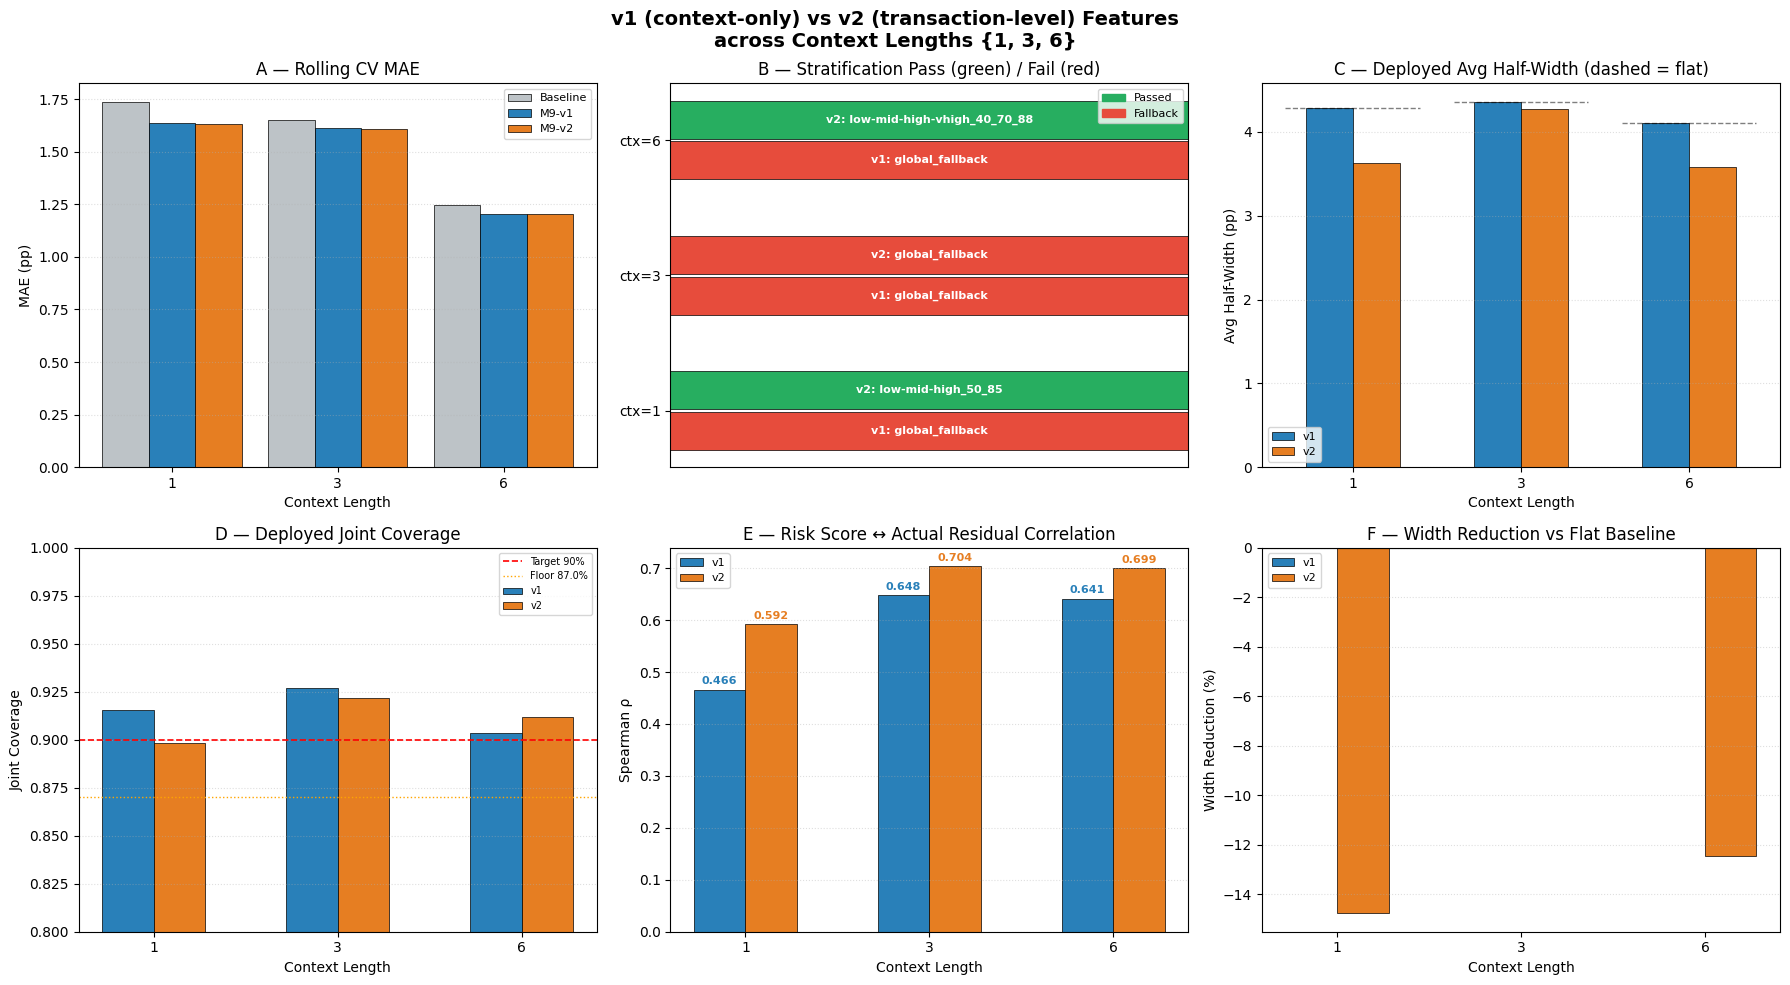

In [10]:
# Separate v1 and v2 results
rv1 = [r for r in results if r['version'] == 'v1']
rv2 = [r for r in results if r['version'] == 'v2']
ctx_labels = [str(r['ctx_len']) for r in rv1]
x = np.arange(len(ctx_labels))
bw = 0.28

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('v1 (context-only) vs v2 (transaction-level) Features\n'
             'across Context Lengths {1, 3, 6}',
             fontsize=14, fontweight='bold')

c_base = '#bdc3c7'
c_v1   = '#2980b9'
c_v2   = '#e67e22'

# ── Panel A: CV MAE ──────────────────────────────────────────────────────────
ax = axes[0, 0]
bars_base = ax.bar(x - bw, [r['cv_baseline_mae'] for r in rv1], bw,
                   label='Baseline', color=c_base, edgecolor='k', lw=0.5)
bars_v1   = ax.bar(x,      [r['cv_m9_mae'] for r in rv1], bw,
                   label='M9-v1', color=c_v1, edgecolor='k', lw=0.5)
if rv2:
    bars_v2 = ax.bar(x + bw, [r['cv_m9_mae'] for r in rv2], bw,
                     label='M9-v2', color=c_v2, edgecolor='k', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(ctx_labels)
ax.set_xlabel('Context Length'); ax.set_ylabel('MAE (pp)')
ax.set_title('A — Rolling CV MAE'); ax.legend(fontsize=8)
ax.grid(axis='y', ls=':', alpha=0.4)

# ── Panel B: Stratification pass/fail ─────────────────────────────────────────
ax = axes[0, 1]
y_pos = np.arange(len(ctx_labels))
for i, r in enumerate(rv1):
    c = '#27ae60' if r.get('strat_passed') else '#e74c3c'
    ax.barh(y_pos[i] - 0.15, 1, 0.28, color=c, edgecolor='k', lw=0.5)
    ax.text(0.5, y_pos[i] - 0.15, f'v1: {r.get("strat_scheme", "?")}',
            ha='center', va='center', fontsize=8, fontweight='bold', color='white')
if rv2:
    for i, r in enumerate(rv2):
        c = '#27ae60' if r.get('strat_passed') else '#e74c3c'
        ax.barh(y_pos[i] + 0.15, 1, 0.28, color=c, edgecolor='k', lw=0.5)
        ax.text(0.5, y_pos[i] + 0.15, f'v2: {r.get("strat_scheme", "?")}',
                ha='center', va='center', fontsize=8, fontweight='bold', color='white')
ax.set_yticks(y_pos); ax.set_yticklabels([f'ctx={c}' for c in ctx_labels])
ax.set_xlim(0, 1); ax.set_xticks([])
ax.set_title('B — Stratification Pass (green) / Fail (red)')
ax.legend([mpatches.Patch(color='#27ae60'), mpatches.Patch(color='#e74c3c')],
          ['Passed', 'Fallback'], fontsize=8)

# ── Panel C: Deployed avg half-width ──────────────────────────────────────────
ax = axes[0, 2]
ax.bar(x - bw/2, [r['strat_avg_hw'] for r in rv1], bw,
       label='v1', color=c_v1, edgecolor='k', lw=0.5)
if rv2:
    ax.bar(x + bw/2, [r['strat_avg_hw'] for r in rv2], bw,
           label='v2', color=c_v2, edgecolor='k', lw=0.5)
# Show flat baseline as reference
for i, r in enumerate(rv1):
    ax.plot([x[i] - 0.4, x[i] + 0.4], [r['flat_avg_hw']]*2, 'k--', lw=1, alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels(ctx_labels)
ax.set_xlabel('Context Length'); ax.set_ylabel('Avg Half-Width (pp)')
ax.set_title('C — Deployed Avg Half-Width (dashed = flat)')
ax.legend(fontsize=8); ax.grid(axis='y', ls=':', alpha=0.4)

# ── Panel D: Deployed joint coverage ──────────────────────────────────────────
ax = axes[1, 0]
ax.bar(x - bw/2, [r['strat_joint_cov'] for r in rv1], bw,
       label='v1', color=c_v1, edgecolor='k', lw=0.5)
if rv2:
    ax.bar(x + bw/2, [r['strat_joint_cov'] for r in rv2], bw,
           label='v2', color=c_v2, edgecolor='k', lw=0.5)
ax.axhline(TARGET_COV, color='red', ls='--', lw=1.2, label=f'Target {TARGET_COV:.0%}')
ax.axhline(TARGET_COV - VOL_TEST_COV_SLACK, color='orange', ls=':', lw=1,
           label=f'Floor {TARGET_COV - VOL_TEST_COV_SLACK:.1%}')
ax.set_xticks(x); ax.set_xticklabels(ctx_labels)
ax.set_xlabel('Context Length'); ax.set_ylabel('Joint Coverage')
ax.set_title('D — Deployed Joint Coverage')
ax.legend(fontsize=7); ax.grid(axis='y', ls=':', alpha=0.4)
ax.set_ylim(0.80, 1.0)

# ── Panel E: Spearman rho ─────────────────────────────────────────────────────
ax = axes[1, 1]
ax.bar(x - bw/2, [r.get('spearman_rho', 0) for r in rv1], bw,
       label='v1', color=c_v1, edgecolor='k', lw=0.5)
if rv2:
    ax.bar(x + bw/2, [r.get('spearman_rho', 0) for r in rv2], bw,
           label='v2', color=c_v2, edgecolor='k', lw=0.5)
for i, r in enumerate(rv1):
    ax.text(x[i] - bw/2, r.get('spearman_rho', 0) + 0.01,
            f'{r.get("spearman_rho",0):.3f}', ha='center', fontsize=8, fontweight='bold', color=c_v1)
if rv2:
    for i, r in enumerate(rv2):
        ax.text(x[i] + bw/2, r.get('spearman_rho', 0) + 0.01,
                f'{r.get("spearman_rho",0):.3f}', ha='center', fontsize=8, fontweight='bold', color=c_v2)
ax.set_xticks(x); ax.set_xticklabels(ctx_labels)
ax.set_xlabel('Context Length'); ax.set_ylabel('Spearman ρ')
ax.set_title('E — Risk Score ↔ Actual Residual Correlation')
ax.legend(fontsize=8); ax.grid(axis='y', ls=':', alpha=0.4)

# ── Panel F: Width reduction % ────────────────────────────────────────────────
ax = axes[1, 2]
ax.bar(x - bw/2, [r.get('width_reduction_pct', 0) for r in rv1], bw,
       label='v1', color=c_v1, edgecolor='k', lw=0.5)
if rv2:
    ax.bar(x + bw/2, [r.get('width_reduction_pct', 0) for r in rv2], bw,
           label='v2', color=c_v2, edgecolor='k', lw=0.5)
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(ctx_labels)
ax.set_xlabel('Context Length'); ax.set_ylabel('Width Reduction (%)')
ax.set_title('F — Width Reduction vs Flat Baseline')
ax.legend(fontsize=8); ax.grid(axis='y', ls=':', alpha=0.4)

plt.tight_layout()
plt.show()

## §9 · Risk Feature Importances by Context Length

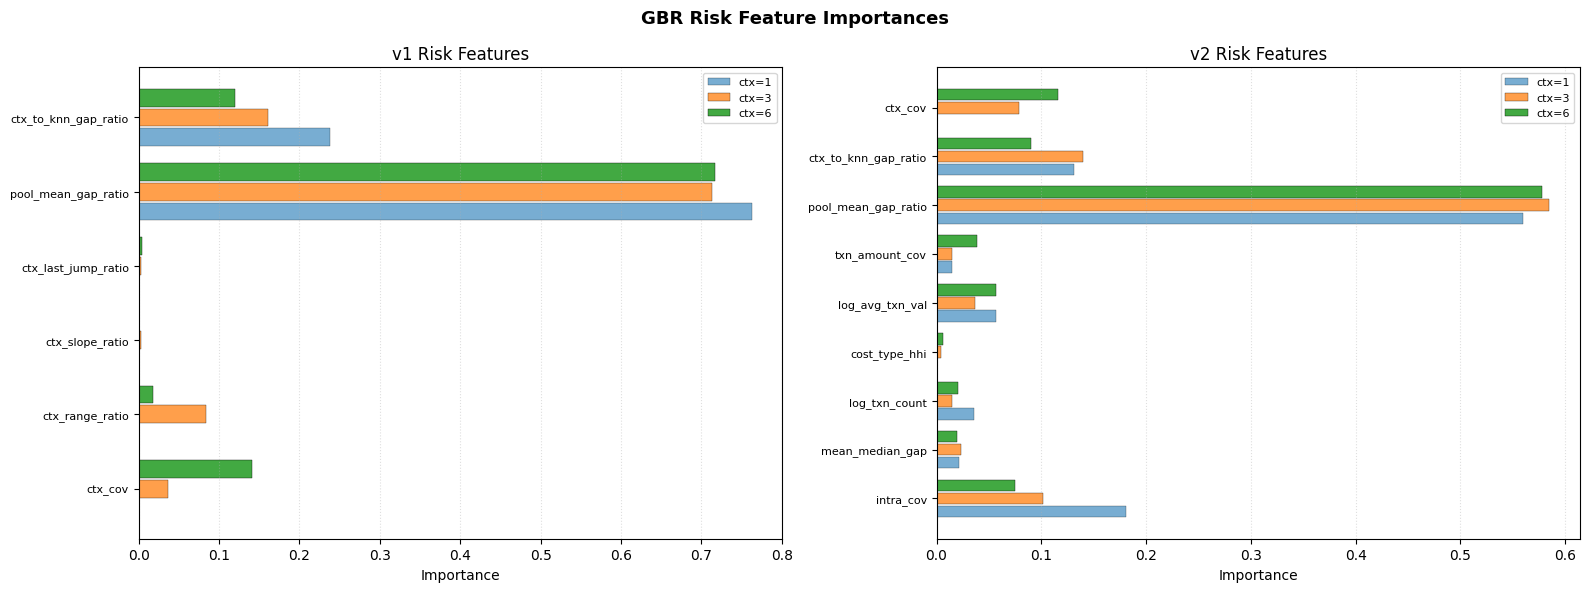

In [11]:
# Compare feature importances across ctx_lens for v1 and v2
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('GBR Risk Feature Importances', fontsize=13, fontweight='bold')

for ax, version, colour, feat_names in [
    (axes[0], 'v1', c_v1, RISK_NAMES_V1),
    (axes[1], 'v2', c_v2, RISK_NAMES_V2),
]:
    rv = [r for r in results if r['version'] == version and 'feature_importances' in r]
    if not rv:
        ax.set_visible(False)
        continue

    n_feat = len(feat_names)
    n_ctx  = len(rv)
    bar_h  = 0.8 / n_ctx
    y_base = np.arange(n_feat)

    for j, r in enumerate(rv):
        imp = [r['feature_importances'].get(fn, 0) for fn in feat_names]
        ax.barh(y_base + j * bar_h, imp, bar_h * 0.9,
                label=f'ctx={r["ctx_len"]}', alpha=0.6 + 0.15 * j,
                edgecolor='k', lw=0.3)

    ax.set_yticks(y_base + bar_h * (n_ctx - 1) / 2)
    ax.set_yticklabels(feat_names, fontsize=8)
    ax.set_xlabel('Importance')
    ax.set_title(f'{version} Risk Features')
    ax.legend(fontsize=8)
    ax.grid(axis='x', ls=':', alpha=0.4)

plt.tight_layout()
plt.show()

## Summary

In [13]:
# Final comparison table
summary_rows = []
for r in results:
    if 'error' in r:
        continue
    summary_rows.append({
        'Context': r['ctx_len'],
        'Version': r['version'],
        'CV MAE': f'{r["cv_m9_mae"]:.4f}',
        'CV Impr%': f'{r["cv_impr_pct"]:+.2f}%',
        'Test MAE': f'{r["test_mae"]:.4f}',
        'Flat Cov': f'{r["flat_joint_cov"]:.3f}',
        'Flat HW': f'±{r["flat_avg_hw"]:.3f}',
        'Strat': '✓' if r['strat_passed'] else '✗',
        'Scheme': r['strat_scheme'],
        'Strat Cov': f'{r["strat_joint_cov"]:.3f}',
        'Strat HW': f'±{r["strat_avg_hw"]:.3f}',
        'ΔWidth': f'{r["width_reduction_pct"]:+.1f}%',
        'ρ': f'{r.get("spearman_rho", 0):.3f}',
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary.style.set_caption(
    'Unified Evaluation: v1 (context-only) vs v2 (transaction-level) Features'
))

,Context,Version,CV MAE,CV Impr%,Test MAE,Flat Cov,Flat HW,Strat,Scheme,Strat Cov,Strat HW,ΔWidth,ρ
0,1,v1,1.6347,-5.97%,1.3176,0.915,±4.290,✗,global_fallback,0.915,±4.290,+0.0%,0.466
1,1,v2,1.6303,-6.23%,1.3165,0.916,±4.259,✓,low-mid-high_50_85,0.898,±3.630,-14.8%,0.592
2,3,v1,1.6114,-2.49%,1.2792,0.927,±4.362,✗,global_fallback,0.927,±4.362,+0.0%,0.648
3,3,v2,1.6101,-2.56%,1.2906,0.922,±4.277,✗,global_fallback,0.922,±4.277,+0.0%,0.704
4,6,v1,1.2026,-3.70%,1.2448,0.904,±4.110,✗,global_fallback,0.904,±4.110,+0.0%,0.641
5,6,v2,1.2034,-3.63%,1.2476,0.904,±4.092,✓,low-mid-high-vhigh_40_70_88,0.912,±3.582,-12.5%,0.699


In [14]:
# Extract compact results for analysis
for r in results:
    v = r['version']
    c = r['ctx_len']
    if 'error' in r:
        print(f"ctx={c} {v}: ERROR — {r['error']}")
        continue
    print(f"ctx={c} {v}: "
          f"CV_base={r['cv_baseline_mae']:.4f}  CV_m9={r['cv_m9_mae']:.4f} ({r['cv_impr_pct']:+.2f}%)  "
          f"test_MAE={r['test_mae']:.4f}  "
          f"flat_cov={r['flat_joint_cov']:.3f} flat_hw={r['flat_avg_hw']:.3f}  "
          f"strat={'PASS' if r['strat_passed'] else 'FAIL'}({r['strat_scheme']}) "
          f"strat_cov={r['strat_joint_cov']:.3f} strat_hw={r['strat_avg_hw']:.3f}  "
          f"ΔW={r['width_reduction_pct']:+.1f}%  "
          f"ρ={r.get('spearman_rho',0):.3f}(p={r.get('spearman_p',1):.2e})")
print()
# Feature importances
for r in results:
    if 'feature_importances' in r:
        fi = r['feature_importances']
        top3 = sorted(fi.items(), key=lambda x: -x[1])[:3]
        print(f"ctx={r['ctx_len']} {r['version']} top-3 risk feats: "
              f"{', '.join(f'{k}={v:.3f}' for k,v in top3)}")

ctx=1 v1: CV_base=1.7385  CV_m9=1.6347 (-5.97%)  test_MAE=1.3176  flat_cov=0.915 flat_hw=4.290  strat=FAIL(global_fallback) strat_cov=0.915 strat_hw=4.290  ΔW=+0.0%  ρ=0.466(p=1.38e-108)
ctx=1 v2: CV_base=1.7385  CV_m9=1.6303 (-6.23%)  test_MAE=1.3165  flat_cov=0.916 flat_hw=4.259  strat=PASS(low-mid-high_50_85) strat_cov=0.898 strat_hw=3.630  ΔW=-14.8%  ρ=0.592(p=6.06e-190)
ctx=3 v1: CV_base=1.6525  CV_m9=1.6114 (-2.49%)  test_MAE=1.2792  flat_cov=0.927 flat_hw=4.362  strat=FAIL(global_fallback) strat_cov=0.927 strat_hw=4.362  ΔW=+0.0%  ρ=0.648(p=2.84e-228)
ctx=3 v2: CV_base=1.6525  CV_m9=1.6101 (-2.56%)  test_MAE=1.2906  flat_cov=0.922 flat_hw=4.277  strat=FAIL(global_fallback) strat_cov=0.922 strat_hw=4.277  ΔW=+0.0%  ρ=0.704(p=1.20e-286)
ctx=6 v1: CV_base=1.2488  CV_m9=1.2026 (-3.70%)  test_MAE=1.2448  flat_cov=0.904 flat_hw=4.110  strat=FAIL(global_fallback) strat_cov=0.904 strat_hw=4.110  ΔW=+0.0%  ρ=0.641(p=1.57e-204)
ctx=6 v2: CV_base=1.2488  CV_m9=1.2034 (-3.63%)  test_MAE=1.2

In [23]:

# Pre-extract horizon years from cached scenarios (avoid repr overhead)
_horizon_years_by_ctx = {}
for cl in CONTEXT_LENS:
    yrs = []
    mids = []
    for s in scenarios_by_ctx[cl]:
        yrs.append(int(s['horizon_data'].iloc[0]['year']))
        mids.append(s['merchant_id'])
    _horizon_years_by_ctx[cl] = (yrs, mids)
print("extracted")


extracted


In [25]:

import collections as _c, io, sys
buf = io.StringIO()
buf.write("DATA: 2010-2019 (10 years)\n\n")
for cl in CONTEXT_LENS:
    yrs, mids = _horizon_years_by_ctx[cl]
    rng_s = np.random.default_rng(42)
    all_m = sorted(set(mids))
    perm = rng_s.permutation(len(all_m))
    n=len(all_m); nt=int(0.60*n)
    tr_m = set(all_m[i] for i in perm[:nt])
    tr_yrs = [y for y, m in zip(yrs, mids) if m in tr_m]
    yr_c = dict(sorted(_c.Counter(tr_yrs).items()))
    uy = sorted(yr_c.keys())
    ci_yrs = sorted(set(yrs))
    buf.write(f"ctx={cl}: {len(uy)} train years, {len(uy)-1} CV folds\n")
    buf.write(f"  years: {uy}\n")
    cum=0
    for i,y in enumerate(uy):
        if i==0: cum+=yr_c[y]; continue
        buf.write(f"  cut={y}: tr={cum:,} te={yr_c[y]:,}\n")
        cum+=yr_c[y]
    buf.write(f"  conformal: cal={ci_yrs[-2]} test={ci_yrs[-1]}\n\n")
sys.stderr.write(buf.getvalue())


DATA: 2010-2019 (10 years)

ctx=1: 10 train years, 9 CV folds
  years: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
  cut=2011: tr=4,847 te=5,496
  cut=2012: tr=10,343 te=5,647
  cut=2013: tr=15,990 te=5,652
  cut=2014: tr=21,642 te=5,664
  cut=2015: tr=27,306 te=5,791
  cut=2016: tr=33,097 te=5,649
  cut=2017: tr=38,746 te=5,776
  cut=2018: tr=44,522 te=5,811
  cut=2019: tr=50,333 te=3,853
  conformal: cal=2018 test=2019

ctx=3: 10 train years, 9 CV folds
  years: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
  cut=2011: tr=3,713 te=5,158
  cut=2012: tr=8,871 te=5,291
  cut=2013: tr=14,162 te=5,294
  cut=2014: tr=19,456 te=5,447
  cut=2015: tr=24,903 te=5,561
  cut=2016: tr=30,464 te=5,458
  cut=2017: tr=35,922 te=5,467
  cut=2018: tr=41,389 te=5,532
  cut=2019: tr=46,921 te=3,618
  conformal: cal=2018 test=2019

ctx=6: 10 train years, 9 CV folds
  years: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
  cut=2011: tr=2,340 te=4,871
  cut=201

1271